## Heart Disease

### Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# from ucimlrepo import fetch_ucirepo


### Load dataset

In [2]:
heart_disease = pd.read_csv('../datasets/heart-disease.csv')

heart_disease.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Data Processing

In [ ]:
# Check Missiong Values
heart_disease.isnull().sum()
heart_disease.dropna(inplace=True)

# Check for duplicates
# heart_disease.duplicated().sum()
# heart_disease.drop_duplicates(inplace=True)

### Check for outliers

### Correlation Matrix

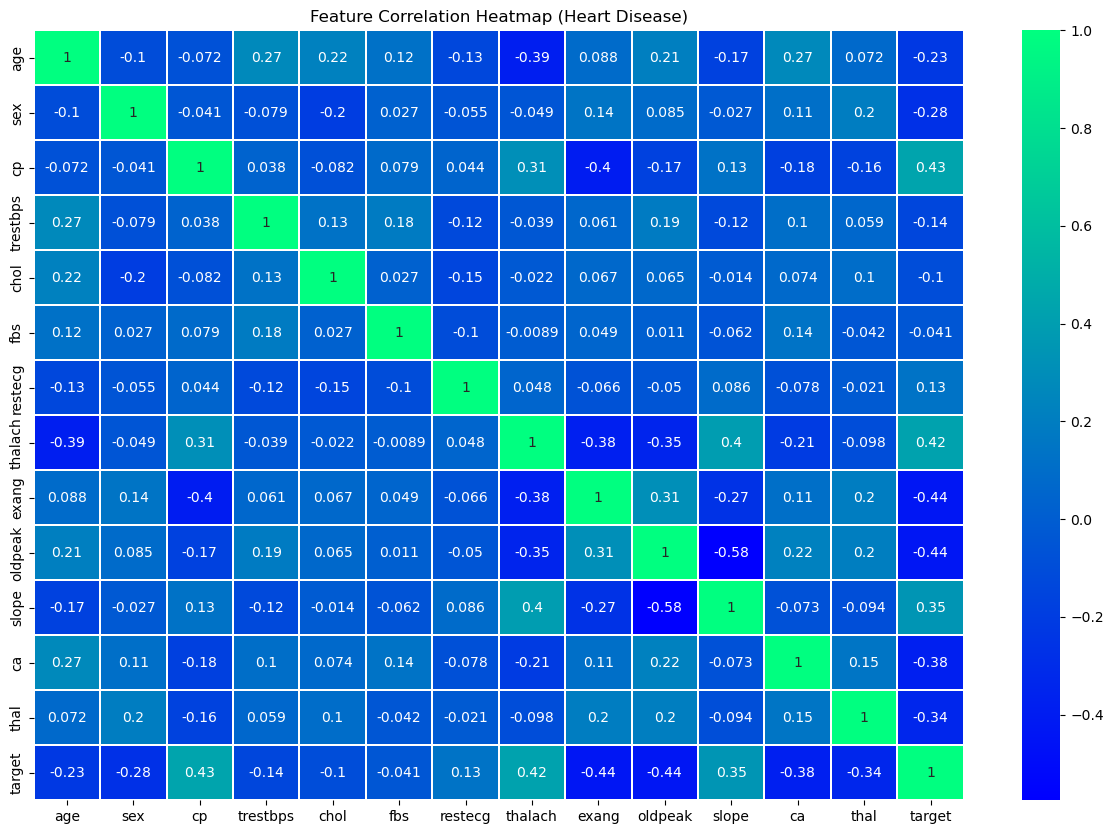

In [6]:
# Compute the correlation matrix
correlation_matrix = heart_disease.corr(method="pearson")

# # Plot the heatmap
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
# plt.title("Feature Correlation Heatmap")
# plt.show()

plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix,linewidth=.01,annot=True,cmap="winter")
plt.title("Feature Correlation Heatmap (Heart Disease)")
plt.show()
# plt.savefig('correlationfigure')

#### Focus on Relevant Features: 
Look at the correlation between the target column (target) and other features. Select features with a strong correlation (positive or negative). As a general rule:

- Correlation ≥ 0.3 or ≤ -0.3 is often considered meaningful.
- Avoid highly correlated features (multicollinearity).

#### Based on the visual data:

- cp (Chest Pain Type): **Correlation: 0.43 (positive)**
  - Chest pain is a primary symptom of heart disease. Different types of chest pain (e.g., angina, non-anginal pain) are strong indicators of cardiac issues.

- thalach (Maximum Heart Rate Achieved): **Correlation: 0.42 (positive)**
  - Maximum heart rate achieved during physical exertion is a measure of cardiovascular fitness.

- ca (Number of Major Vessels Colored by Fluoroscopy): **Correlation: -0.38 (negative)**
  - Fewer blocked vessels correlate with better heart health, while an increased number correlates with higher risk and severity of heart disease. This explains the negative correlation.

- oldpeak (ST Depression Induced by Exercise Relative to Rest): **Correlation: -0.44 (negative)**
  - ST depression is a key finding in stress tests and indicates ischemia (reduced blood flow to the heart). Higher values of oldpeak signify worse cardiac ischemia and are directly linked to a higher likelihood of heart disease.

- thal (Thalassemia): **Correlation: -0.34 (negative)**
  - Thalassemia refers to genetic abnormalities in hemoglobin. In the context of heart disease, abnormal thal values may reflect underlying issues like stress-induced ischemia or previous heart damage, making it moderately predictive.

- exang (Exercise-Induced Angina): **Correlation: -0.44 (negative)**
  - Exercise-induced angina (chest pain during exercise) is a hallmark symptom of coronary artery disease. If a person experiences angina during physical activity, it indicates that the heart is not receiving adequate blood supply due to narrowed or blocked arteries.

#### Less Relevant Features
- Features like age, sex, chol, fbs, and restecg show weaker correlations (close to 0) and may contribute less to the prediction of the target.

In [9]:
# Keep only relevant features
relevant_features = ['cp', 'thalach', 'ca', 'oldpeak', 'thal', 'exang']
heart_disease_featurized = heart_disease[relevant_features]


### Exploratory Data Analysis - EDA

#### Distribution Plots

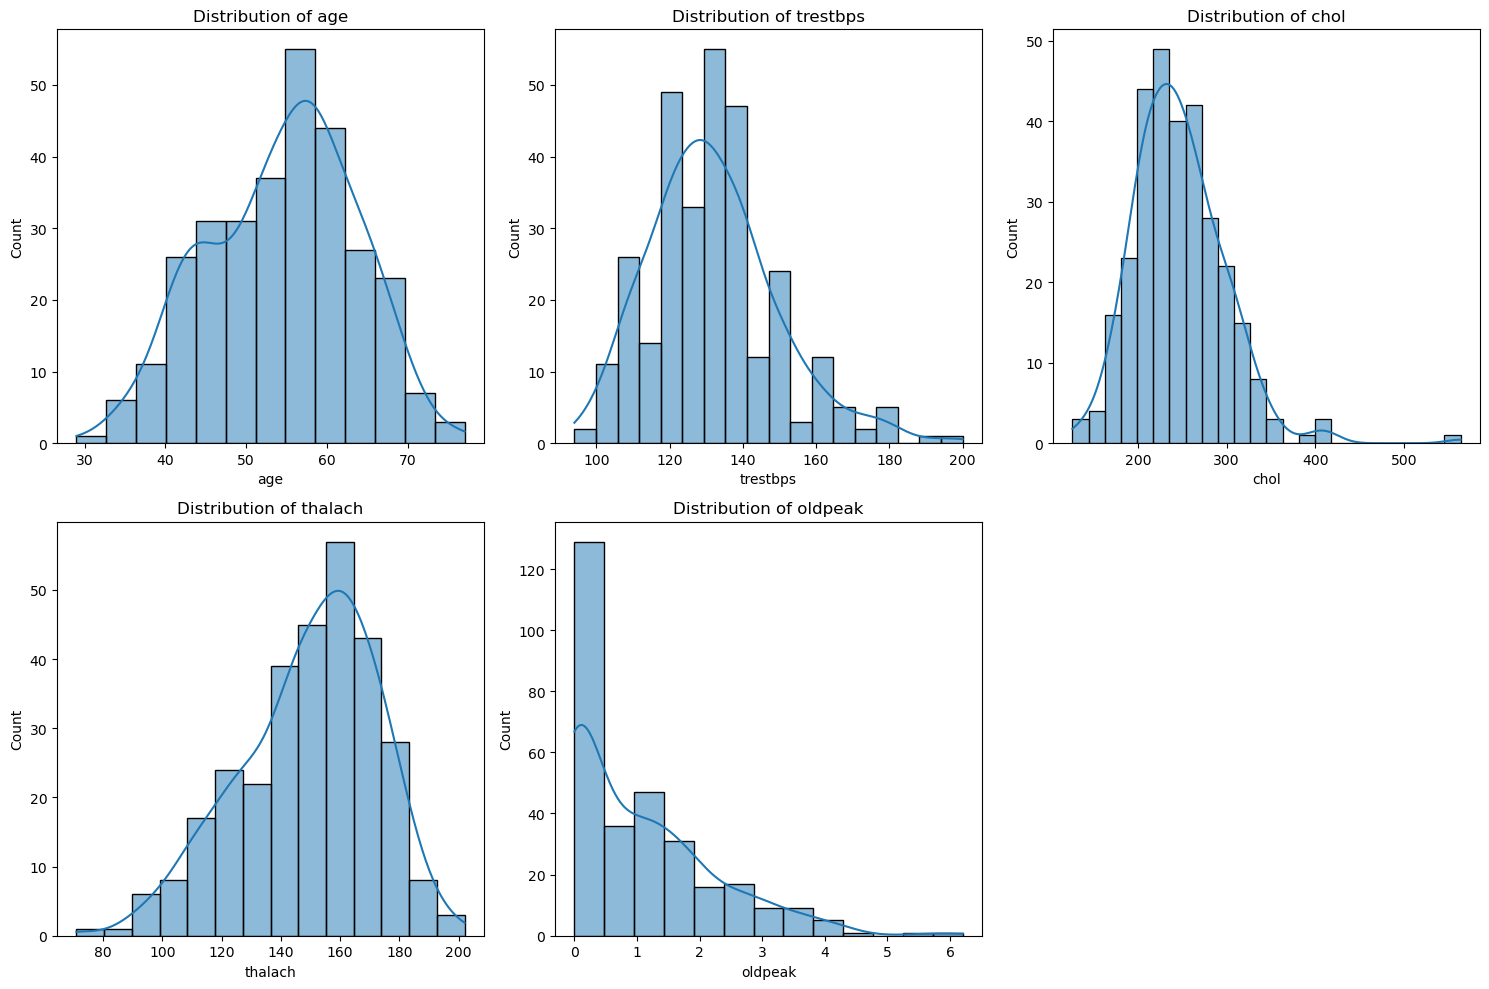

In [22]:
# Plot distribution of key features
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(heart_disease[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

#### Plot boxplots for key features

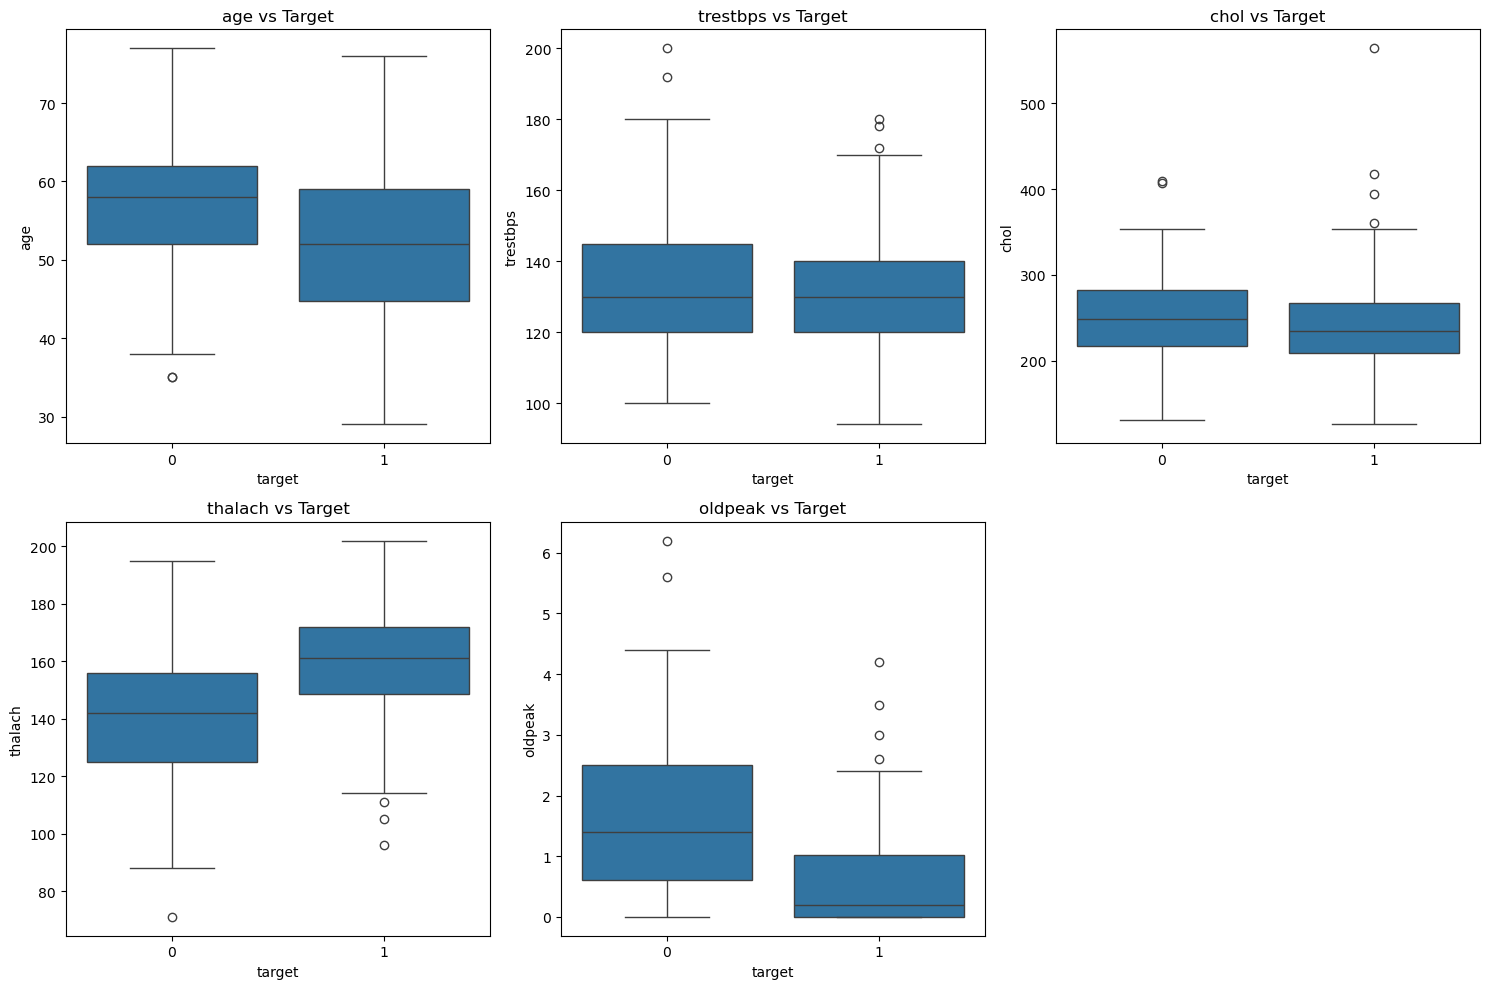

In [23]:
# Plot boxplots for key features against the target variable
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='target', y=feature, data=heart_disease)
    plt.title(f'{feature} vs Target')
plt.tight_layout()
plt.show()